TASK 2: Unemployment Analysis with Python

● Analyze unemployment rate data representing unemployed people percentage.

● Use Python for data cleaning, exploration, and visualization of unemployment  trends.

● Investigate the impact of Covid-19 on unemployment rates.

● Identify key patterns or seasonal trends in the data.

● Present insights that could inform economic or social policies.

In [1]:
import pandas as pd;

In [2]:
import pandas as pd
df_draft = pd.read_csv(r'/content/Unemployment in India.csv')

# **Data Cleaning**

In [3]:
df_draft.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df_draft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 41.4+ KB


Data Cleaning : Remove Null Values

In [5]:
df_draft.isnull().sum()

,0
Region,14
Date,14
Frequency,14
Estimated Unemployment Rate (%),14
Estimated Employed,14
Estimated Labour Participation Rate (%),14
Area,14


In [6]:
df_draft.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [7]:
df_draft.shape

(754, 7)

In [8]:
df_draft = df_draft.dropna()

In [9]:
df_draft.tail(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
744,West Bengal,30-09-2019,Monthly,7.79,11158649.0,45.74,Urban
745,West Bengal,31-10-2019,Monthly,7.83,10563686.0,43.25,Urban
746,West Bengal,30-11-2019,Monthly,6.61,10768462.0,43.44,Urban
747,West Bengal,31-12-2019,Monthly,7.24,11335696.0,45.97,Urban
748,West Bengal,31-01-2020,Monthly,7.27,11208617.0,45.39,Urban
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban
753,West Bengal,30-06-2020,Monthly,9.86,9088931.0,37.57,Urban


Data Cleaning : Remove Duplicates

In [10]:
df_draft.duplicated().sum()

np.int64(0)

In [11]:
df_draft.drop_duplicates()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [12]:
print("Missing values per column:")
display(df_draft.isnull().sum())

Missing values per column:


,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [13]:
df_draft = df_draft.drop(columns=[' Frequency'])

In [14]:
df_draft.columns

Index(['Region', ' Date', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [15]:
df_draft.columns = df_draft.columns.str.strip()
df_draft.columns

Index(['Region', 'Date', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [16]:
df_draft['Date'] = pd.to_datetime(df_draft['Date'], dayfirst=True)

df_draft['Region'] = df_draft['Region'].astype('category')
df_draft['Area'] = df_draft['Area'].astype('category')

df_draft.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    category      
 1   Date                                     740 non-null    datetime64[ns]
 2   Estimated Unemployment Rate (%)          740 non-null    float64       
 3   Estimated Employed                       740 non-null    float64       
 4   Estimated Labour Participation Rate (%)  740 non-null    float64       
 5   Area                                     740 non-null    category      
dtypes: category(2), datetime64[ns](1), float64(3)
memory usage: 47.9 KB


In [17]:
df_visual = df_draft[['Estimated Unemployment Rate (%)', 'Estimated Employed','Estimated Labour Participation Rate (%)' ]]


array([[<Axes: title={'center': 'Estimated Unemployment Rate (%)'}>,
        <Axes: title={'center': 'Estimated Employed'}>],
       [<Axes: title={'center': 'Estimated Labour Participation Rate (%)'}>,
        <Axes: >]], dtype=object)

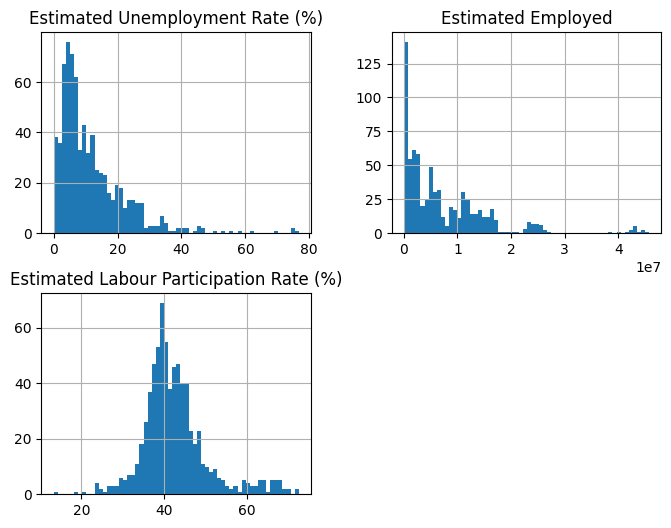

In [18]:
df_visual.hist(bins=60, figsize=(8,6))



### Investigate the impact of Covid-19 on unemployment rates.

In [19]:
df_draft['Date'] = pd.to_datetime(df_draft['Date'], dayfirst=True)

df_draft['year'] = df_draft['Date'].dt.year
df_draft['month'] = df_draft['Date'].dt.month

def categorize_period(row):
    if row['year'] == 2020 and row['month'] >= 3:
        return 'During Covid-19'
    else:
        return 'Before Covid-19'

df_draft['Period'] = df_draft.apply(categorize_period, axis=1)

display(df_draft.head(10))

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,year,month,Period
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural,2019,5,Before Covid-19
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural,2019,6,Before Covid-19
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural,2019,7,Before Covid-19
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural,2019,8,Before Covid-19
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural,2019,9,Before Covid-19
5,Andhra Pradesh,2019-10-31,3.52,12017412.0,43.01,Rural,2019,10,Before Covid-19
6,Andhra Pradesh,2019-11-30,4.12,11397681.0,41.00,Rural,2019,11,Before Covid-19
7,Andhra Pradesh,2019-12-31,4.38,12528395.0,45.14,Rural,2019,12,Before Covid-19
8,Andhra Pradesh,2020-01-31,4.84,12016676.0,43.46,Rural,2020,1,Before Covid-19
9,Andhra Pradesh,2020-02-29,5.91,11723617.0,42.83,Rural,2020,2,Before Covid-19


In [20]:
import plotly.express as px

covid_impact_df = df_draft.groupby(['Region', 'Period'], observed=False)['Estimated Unemployment Rate (%)'].mean().reset_index()

fig = px.bar(covid_impact_df,x='Region', y='Estimated Unemployment Rate (%)',color = 'Period',
             barmode='group', title='Unemployment Rate Before and During Covid-19',height= 550)
fig.update_layout(xaxis_title= 'Region', yaxis_title='Average Unemployment Rate (%)')
fig.show()

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

###Identify key patterns

### 2. Average Estimated Unemployment Rate by Month (Seasonal Trends)

/tmp/ipykernel_15035/2552178851.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




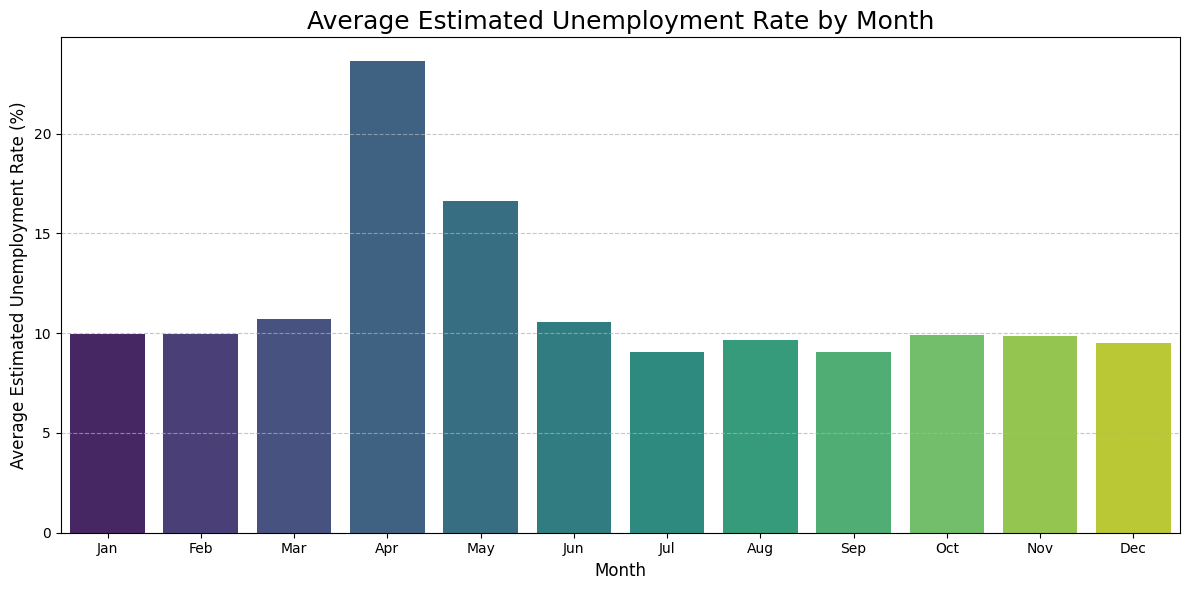

In [22]:
monthly_avg_unemployment = df_draft.groupby('month')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='Estimated Unemployment Rate (%)', data=monthly_avg_unemployment,palette='viridis')# Color palette='viridis'
plt.title('Average Estimated Unemployment Rate by Month', fontsize=18)#
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Estimated Unemployment Rate (%)', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Estimated Unemployment Rate in 2020 by Month (Covid-19 Impact Detail)

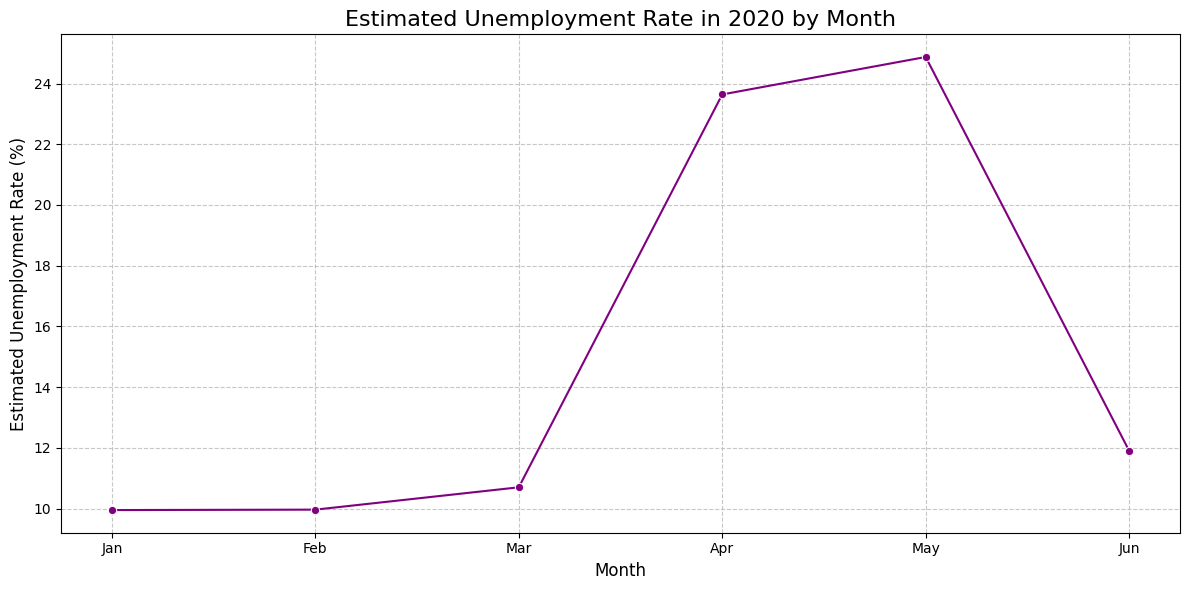

In [23]:
df_2020_monthly = df_draft[df_draft['year'] == 2020].groupby('month')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='Estimated Unemployment Rate (%)', data=df_2020_monthly, marker='o', color='purple')
plt.title('Estimated Unemployment Rate in 2020 by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.xticks(ticks=range(1, 7), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Present insights that could inform economic or social policies.

###Unemployment During COVID-19 in India: Insights

>Before COVID-19, the unemployment rate in India was comparatively low. However, after the outbreak of COVID-19, unemployment increased significantly.

>From the dataset, I observed that the Estimated Unemployment Rate and Estimated Employed columns are right-skewed, while the Estimated Labour Participation Rate column follows a bell-shaped distribution.

###Investigating the Impact of COVID-19 on Unemployment Rates

> I investigated the impact of COVID-19 on the unemployment rate to identify whether there was a decline or an upward trend. I analyzed the COVID-19 impact using bar charts and visualized the changes in unemployment rates.

###Identifying Key Patterns and Seasonal Trends in the Data

> I analyzed seasonal trends using the Month column and the Estimated Unemployment Rate column. The trends were visualized using a histogram for the year 2020.